In [1]:
import pandas as pd
import numpy as np

popularity_df = pd.read_parquet("../data/processed/artist_popularity.parquet")
interactions = pd.read_parquet("../data/processed/interactions.parquet")

print(f"Artists in popularity table: {len(popularity_df):,}")
print(f"Interactions loaded: {len(interactions):,}")

Artists in popularity table: 145,778
Interactions loaded: 3,664,980


In [3]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from src.recommenders.popularity import PopularityRecommender

rec = PopularityRecommender()
rec.fit(popularity_df, interactions)

PopularityRecommender fitted on 145,778 artists.


In [4]:
cold_start_recs = rec.recommend_cold_start(k=10)
print("Cold Start Recommendations (new user):")
print(cold_start_recs.to_string(index=False))

Cold Start Recommendations (new user):
          artist_name  popularity_score  unique_listeners recommendation_source
            radiohead          1.000000             16149 popularity_cold_start
          the beatles          0.999993             15897 popularity_cold_start
             coldplay          0.999986             14006 popularity_cold_start
red hot chili peppers          0.999979             10301 popularity_cold_start
                 muse          0.999973              9802 popularity_cold_start
            metallica          0.999966              9597 popularity_cold_start
           pink floyd          0.999959              9309 popularity_cold_start
          the killers          0.999952              8611 popularity_cold_start
              nirvana          0.999945              8439 popularity_cold_start
          linkin park          0.999938              8289 popularity_cold_start


In [6]:

sample_user = interactions["user_id"].iloc[0]
print(f"User: {sample_user}")
print(f"Artists this user already listens to:")
print(interactions[interactions["user_id"] == sample_user]["artist_name"].tolist())

personalized_recs = rec.recommend(user_id=sample_user, k=10)
print("\nRecommendations (already-heard artists filtered out):")
print(personalized_recs.to_string(index=False))

User: 00000c289a1829a808ac09c00daf10bc3c4e223b
Artists this user already listens to:
['all ends', 'all:my:faults', 'babes in toyland', 'betty', 'betty blowtorch', 'bif naked', 'blue Öyster cult', 'die Ärzte', 'disciple', 'dropkick murphys', 'edguy', 'eluveitie', 'elvenking', 'girlschool', 'goldfrapp', 'guano apes', 'horrorpops', 'jack johnson', 'jack off jill', 'john mayer', 'judas priest', 'juliette & the licks', 'l7', 'le tigre', 'letzte instanz', 'little big town', 'london after midnight', 'lunachicks', 'magica', 'maximum the hormone', 'melissa etheridge', 'mutyumu', 'rasputina', 'red hot chili peppers', 'rob zombie', 'sandra nasic', 'schandmaul', 'sleater-kinney', 'tanzwut', 'team dresch', 'the black dahlia murder', 'the bosshoss', 'the butchies', 'the killers', 'the murmurs', 'the rolling stones', 'the wallflowers', 'the who', 'walls of jericho']

Recommendations (already-heard artists filtered out):
     artist_name  popularity_score  unique_listeners recommendation_source
      

In [7]:

sample_users = interactions["user_id"].sample(5, random_state=42).tolist()

for uid in sample_users:
    recs = rec.recommend(user_id=uid, k=5)
    print(f"\nUser: {uid[:12]}...")
    print(recs["artist_name"].tolist())


User: 9342a4c269a8...
['coldplay', 'red hot chili peppers', 'muse', 'metallica', 'pink floyd']

User: 9e5b8d29d3c4...
['radiohead', 'the beatles', 'coldplay', 'red hot chili peppers', 'muse']

User: afe27bd965b8...
['radiohead', 'the beatles', 'coldplay', 'red hot chili peppers', 'muse']

User: 50f4ff791ee5...
['red hot chili peppers', 'metallica', 'pink floyd', 'the killers', 'nirvana']

User: 53d51b94cb5d...
['radiohead', 'coldplay', 'red hot chili peppers', 'muse', 'metallica']


Total artists in catalog: 145,778
Top 1,000 artists account for 46.7% of all listener-interactions
Bottom 144,778 artists account for 53.3%

A pure popularity engine effectively ignores 144,778 artists entirely.


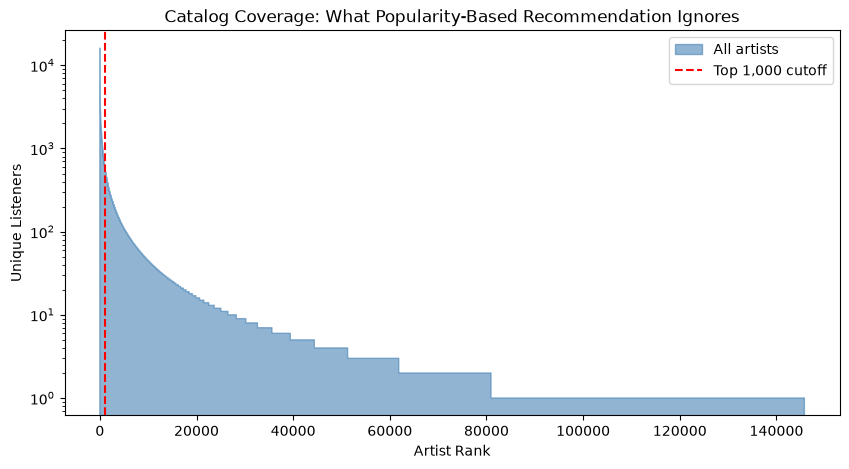

In [9]:
import matplotlib.pyplot as plt



total_artists = len(popularity_df)

top_1000_share = popularity_df.head(1000)["unique_listeners"].sum() / \
                 popularity_df["unique_listeners"].sum() * 100

print(f"Total artists in catalog: {total_artists:,}")
print(f"Top 1,000 artists account for {top_1000_share:.1f}% of all listener-interactions")
print(f"Bottom {total_artists - 1000:,} artists account for {100 - top_1000_share:.1f}%")
print(f"\nA pure popularity engine effectively ignores {total_artists - 1000:,} artists entirely.")

plt.figure(figsize=(10, 5))
plt.fill_between(
    range(len(popularity_df)),
    popularity_df["unique_listeners"].values,
    alpha=0.6, color="steelblue", label="All artists"
)
plt.axvline(x=1000, color="red", linestyle="--", label="Top 1,000 cutoff")
plt.xlabel("Artist Rank")
plt.ylabel("Unique Listeners")
plt.title("Catalog Coverage: What Popularity-Based Recommendation Ignores")
plt.yscale("log")
plt.legend()
plt.savefig("outputs/figures/popularity_coverage_gap.png", dpi=150)
plt.show()

In [10]:


print("=== BASELINE ESTABLISHED ===")
print(f"Model: Popularity-Based Recommender")
print(f"Strategy: Rank by unique_listeners, filter seen artists")
print(f"Catalog coverage: Top ~1,000 of {total_artists:,} artists")
print(f"Personalization: None (same ranking for all users)")
print(f"Cold start capable: Yes")
print(f"Requires interaction history: No")
print(f"Requires audio features: No")
print("================================")

=== BASELINE ESTABLISHED ===
Model: Popularity-Based Recommender
Strategy: Rank by unique_listeners, filter seen artists
Catalog coverage: Top ~1,000 of 145,778 artists
Personalization: None (same ranking for all users)
Cold start capable: Yes
Requires interaction history: No
Requires audio features: No


In [11]:
recs = rec.recommend_cold_start(k=5)

print("Cold Start Top 5 Artists:")
print(recs["artist_name"].tolist())

Cold Start Top 5 Artists:
['radiohead', 'the beatles', 'coldplay', 'red hot chili peppers', 'muse']


In [12]:
# Top 1000 most popular artists
top_1000_artists = set(popularity_df.head(1000)["artist_name"])

# Total listener-interactions
total_interactions = len(interactions)

# Interactions involving the top 1000 artists
top_1000_interactions = interactions[
    interactions["artist_name"].isin(top_1000_artists)
]

# Percentage share
share = (len(top_1000_interactions) / total_interactions) * 100

print(f"Total interactions        : {total_interactions:,}")
print(f"Top-1000 interactions     : {len(top_1000_interactions):,}")
print(f"Top-1000 interaction share: {share:.2f}%")

Total interactions        : 3,664,980
Top-1000 interactions     : 1,712,060
Top-1000 interaction share: 46.71%
